In [2]:
import ssl

ssl._create_default_https_context = ssl._create_unverified_context # TODO: Убрать обход сертификата

import seaborn as sns

df = sns.load_dataset("diamonds")

In [3]:
print(df.head(10))

   carat        cut color clarity  depth  table  price     x     y     z
0   0.23      Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21    Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23       Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29    Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31       Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75
5   0.24  Very Good     J    VVS2   62.8   57.0    336  3.94  3.96  2.48
6   0.24  Very Good     I    VVS1   62.3   57.0    336  3.95  3.98  2.47
7   0.26  Very Good     H     SI1   61.9   55.0    337  4.07  4.11  2.53
8   0.22       Fair     E     VS2   65.1   61.0    337  3.87  3.78  2.49
9   0.23  Very Good     H     VS1   59.4   61.0    338  4.00  4.05  2.39


ДО ОЧИСТКИ:
Среднее: 3932.80
Медиана: 2401.00

ПОСЛЕ ОЧИСТКИ:
Среднее: 3159.46
Медиана: 2155.00


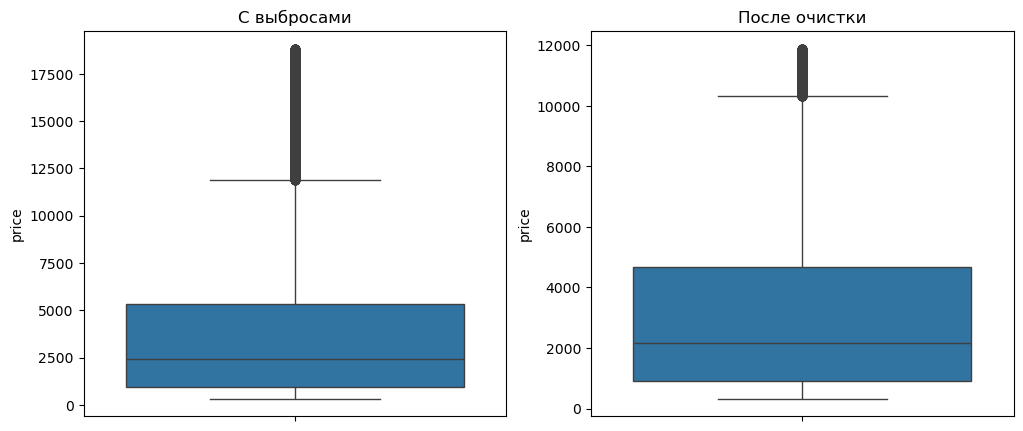

In [4]:
quants = df['price'].quantile([0.25,0.75])
q25 = quants.loc[0.25]
q75 = quants.loc[0.75]
IQR = q75-q25
df_filtered = df[(df['price'] > q25-1.5*IQR) & (df['price'] < q75 + 1.5*IQR)]
print("ДО ОЧИСТКИ:")
print(f"Среднее: {df['price'].mean():.2f}")
print(f"Медиана: {df['price'].median():.2f}\n")

print("ПОСЛЕ ОЧИСТКИ:")
print(f"Среднее: {df_filtered['price'].mean():.2f}")
print(f"Медиана: {df_filtered['price'].median():.2f}")
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, y="price", ax=axes[0])
axes[0].set_title("С выбросами")

sns.boxplot(data=df_filtered, y="price", ax=axes[1])
axes[1].set_title("После очистки")

plt.show()

In [5]:
def remove_outliers_iqr(df, column):
    q25 = df[column].quantile(0.25)
    q75 = df[column].quantile(0.75)
    iqr = q75-q25
    df_filtered = df[(df[column] > q25 - 1.5*iqr) & (df[column] < q75 + 1.5*iqr)]
    print('Процент выброшенных данных:', 1-(len(df_filtered)/len(df)))
    return df_filtered
remove_outliers_iqr(df,'price')

Процент выброшенных данных: 0.06562847608453837


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74
